<a href="https://colab.research.google.com/github/sunjinnn/Python-Education-2026/blob/main/08_%ED%99%9C%EC%9A%A9%ED%8E%B8(7)_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1_%ED%9A%8C%EA%B7%80%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

전체 데이터
    hour  pass
0    0.5     0
1    1.2     0
2    1.8     0
3    2.4     0
4    2.6     0
5    3.2     0
6    3.9     0
7    4.4     1
8    4.5     0
9    5.0     1
10   5.3     1
11   5.8     0
12   6.0     1
13   6.1     1
14   6.2     1
15   6.9     1
16   7.2     1
17   8.4     1
18   8.6     1
19  10.0     1

===== 6시간 공부했을 때 =====
예측 결과: 1
불합격 확률: 14.15 %
합격 확률: 85.85 %

===== 4시간 공부했을 때 =====
예측 결과: 0
불합격 확률: 62.5 %
합격 확률: 37.5 %

===== 테스트 결과 =====
공부 시간:
[ 8.6  1.2 10.   4.5]
실제값:
[1 0 1 0]
예측값:
[1 0 1 1]

모델 정확도: 75.0 %

===== 4.5시간 공부했을 때 =====
불합격 확률: 48.31 %
합격 확률: 51.69 %

혼동 행렬
[[1 1]
 [0 2]]


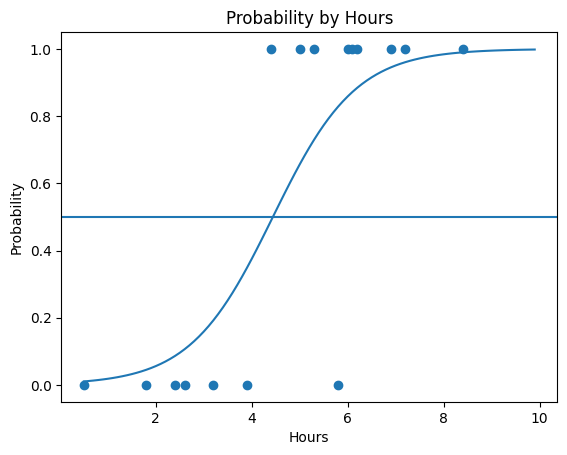

In [14]:
#로지스틱 선형회귀 문제 풀이
#공부 시간에 따른 합격 가능성 계산하기

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


# 1. 데이터셋 생성
data = {
    "hour": [
        0.5, 1.2, 1.8, 2.4, 2.6,
        3.2, 3.9, 4.4, 4.5, 5.0,
        5.3, 5.8, 6.0, 6.1, 6.2,
        6.9, 7.2, 8.4, 8.6, 10.0
    ],

    "pass": [
        0, 0, 0, 0, 0,
        0, 0, 1, 0, 1,
        1, 0, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

dataset = pd.DataFrame(data)

print("전체 데이터")
print(dataset)


# 2. 독립 변수 / 종속 변수
X = dataset[["hour"]].values
y = dataset["pass"].values


# 3. 훈련 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)


# 4. 로지스틱 회귀 모델 생성 및 학습
classifier = LogisticRegression()

classifier.fit(
    X_train,
    y_train
)


# 5. 6시간 공부 시 예측
prediction = classifier.predict([[6]])
probability = classifier.predict_proba([[6]])

print()
print("===== 6시간 공부했을 때 =====")

print("예측 결과:", prediction[0])

print(
    "불합격 확률:",
    round(probability[0][0] * 100, 2),
    "%"
)

print(
    "합격 확률:",
    round(probability[0][1] * 100, 2),
    "%"
)


# 6. 4시간 공부 시 예측
prediction_4 = classifier.predict([[4]])
probability_4 = classifier.predict_proba([[4]])

print()
print("===== 4시간 공부했을 때 =====")

print("예측 결과:", prediction_4[0])

print(
    "불합격 확률:",
    round(probability_4[0][0] * 100, 2),
    "%"
)

print(
    "합격 확률:",
    round(probability_4[0][1] * 100, 2),
    "%"
)


# 7. 테스트 데이터 예측
y_pred = classifier.predict(X_test)

print()
print("===== 테스트 결과 =====")

print("공부 시간:")
print(X_test.reshape(-1))

print("실제값:")
print(y_test)

print("예측값:")
print(y_pred)


# 8. 모델 정확도
score = classifier.score(
    X_test,
    y_test
)

print()
print(
    "모델 정확도:",
    round(score * 100, 2),
    "%"
)


# 9. 4.5시간 예측
probability_45 = classifier.predict_proba([[4.5]])

print()
print("===== 4.5시간 공부했을 때 =====")

print(
    "불합격 확률:",
    round(probability_45[0][0] * 100, 2),
    "%"
)

print(
    "합격 확률:",
    round(probability_45[0][1] * 100, 2),
    "%"
)


# 10. 혼동 행렬
cm = confusion_matrix(
    y_test,
    y_pred
)

print()
print("혼동 행렬")
print(cm)


# 11. 시그모이드 그래프
X_range = np.arange(
    X.min(),
    X.max(),
    0.1
)

p = 1 / (
    1 + np.exp(
        -(classifier.coef_[0][0] * X_range
          + classifier.intercept_[0])
    )
)

plt.scatter(
    X_train.reshape(-1),
    y_train
)

plt.plot(
    X_range,
    p
)

plt.axhline(
    y=0.5
)

plt.title("Probability by Hours")
plt.xlabel("Hours")
plt.ylabel("Probability")

plt.show()